In [1]:
# === Notebook path and directory configuration ===
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
if CWD.name == "diagnostic":
    DIAGNOSTIC_DIR = CWD
elif (CWD / "diagnostic").is_dir():
    DIAGNOSTIC_DIR = CWD / "diagnostic"
else:
    DIAGNOSTIC_DIR = next((p for p in [CWD, *CWD.parents] if p.name == "diagnostic"), CWD.parent)

if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

model_outpath = Path("/compyfs/zhan391/v3_dart_cda_scratch")
dart_outpath = model_outpath

DIAG_OUT_DIR = Path("/compyfs/www/zhan391/e3sm_dart/diag_out")
DIAG_DATA_DIR = DIAG_OUT_DIR / "data"
DIAG_FIGURE_DIR = DIAG_OUT_DIR / "figure"

DIAG_DATA_DIR.mkdir(parents=True, exist_ok=True)
DIAG_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

import os
import warnings
import logging
from collections import defaultdict
from typing import Tuple, List, Dict, Optional

# === Numerical and Data Tools ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xc
import xskillscore as xs

from datetime import datetime

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter

# === Mapping and Projections ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker


from util.dart_obs_diag import (
    DartObsDiagReader
)

# === Suppress warnings globally ===
warnings.filterwarnings("ignore")

from util.dask_helpers import configure_dask, open_dataset_lazy, persist_if_dask


/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
from configs.analysis_da_experiment_config import extract_obs_diag_config

# User setup: edit this dictionary when experiment names, runs, aliases, periods,
# or diagnostic sets change. The shared helper only validates and builds paths.
USER_EXPERIMENTS = {
    "CAM80-S0": {
        "run": "f.e21.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80",
        "period": "2011120100-2012010100",
    },
    "CAM80-S1": {
        "run": "f.e22.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80S1",
        "period": "2012050100-2012060100",
    },
    "CTRL10-S0": {
        "run": "CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "CTRLEN10",
        "period": "2011120100-2012010100",
    },
    "DART10-S0": {
        "run": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "DARTEN10",
        "period": "2011120100-2012010100",
    },
    "DART20-S0": {
        "run": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en20",
        "alias": "DARTEN20",
        "period": "2011120100-2012010100",
    },
    "DART40INF0p6-S0": {
        "run": "DARTEN40_INF0p6_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S0": {
        "run": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S1": {
        "run": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40S1",
        "period": "2012050100-2012060100",
    },
}

# User setup: change this tuple when the available diagnostic sets change.
USER_DIAG_SETS = ("obs_seq", "obs_diag", "obs_common", "closest_member", "cam6_common")

# Optional layer for temporary add/update/remove changes. Set an experiment to None
# here to remove it without touching USER_EXPERIMENTS.
USER_EXPERIMENT_OVERRIDES = {}


def extract_exp_info(exp_name: str = None) -> dict:
    return extract_obs_diag_config(
        exp_name=exp_name,
        experiments=USER_EXPERIMENTS,
        data_path=dart_outpath,
        diag_sets=USER_DIAG_SETS,
        experiment_overrides=USER_EXPERIMENT_OVERRIDES,
    )

In [3]:
class ObsDiagPlotter:
    def __init__(
        self, var, var_dict, data_dict, fig_path,
        plevstr, regnam=None
    ):
        self.var = var
        self.var_dict = var_dict or {}
        self.data_dict = data_dict or {}
        self.fig_path = fig_path
        self.plevstr = plevstr or []
        self.regnam = regnam
        self._prepare_common()

    def _prepare_common(self):
        self.cmap = {
            'blue': '#377eb8', 'orange': '#ff7f00', 'green': '#4daf4a',
            'pink': '#f781bf', 'brown': '#a65628', 'purple': '#984ea3',
            'gray': '#999999', 'red': '#e41a1c', 'yellow': '#dede00'
        }

    def _set_axes_limits(self, ax, xlim=None, ylim=None, yticks=None, xticks=None):
        if xlim is not None: ax.set_xlim(*xlim)
        if ylim is not None: ax.set_ylim(*ylim)
        if yticks is not None: ax.set_yticks(yticks)
        if xticks is not None: ax.set_xticks(xticks)

    # NEW: robust getter for inner var-config
    def _varcfg(self):
        """Return inner var-config whether var_dict is an inner dict or a single-entry wrapper."""
        vd = self.var_dict
        if isinstance(vd, dict) and 'y1aix' in vd:
            return vd
        if isinstance(vd, dict) and len(vd) == 1:
            return next(iter(vd.values()))
        raise ValueError(
            "var_dict not recognized. Pass inner dict with keys like 'y1aix'/'y2aix', "
            "or a single-entry wrapper {var_key: inner}."
        )

    def check_flat_lev_consistency(self, lev_dict):
        ref_var = next(iter(lev_dict))
        reference = lev_dict[ref_var]
        for var, lev in lev_dict.items():
            if lev != reference:
                raise ValueError(
                    f"Inconsistent pressure level list for variable '{var}'.\n"
                    f"Expected: {reference}\nFound:    {lev}"
                )
        print("All level lists are consistent across variables.")
        return reference
    
    def build_ts_var_dict(
        self, var_key: str = None, name: str = None,
        y1axis: list = None, y2axis: list = None
    ) -> dict:
        var_key = var_key or 'RADIOSONDE_U'
        name = name or 'RADIOSONDE_U_WIND_COMPONENT'
        entry = {
            'name': name,
            'lev_type': 'pressure',
            'CopySpread': 'totalspread',
            'CopyRMSE': 'rmse',
            'CopyNposs': 'Nposs',
            'CopyNused': 'Nused',
            'type1': 'guess',
            'type2': 'VPguess',
            'type3': 'guess_RankHist',
            'y1aix': y1axis if y1axis is not None else [0, 10],
            'y2aix': [0, 100],
            'y1aix0': y2axis if y2axis is not None else [0, 10],
            'y2aix0': [0, 100],
        }
        return {var_key: entry}
    
    def compute_experiment_means(self, data_dict, diagnostic_keys_to_average, persist=False):
        """Average selected diagnostics across matched observation types."""
        if not data_dict:
            raise ValueError("data_dict is empty; cannot compute means.")

        sample_var_data = next(iter(data_dict.values()))
        experiments = list(sample_var_data.keys())
        all_diagnostic_keys = set()
        for var_data in data_dict.values():
            for exp_data in var_data.values():
                all_diagnostic_keys.update(exp_data.keys())

        mean_dict = {}
        for exp in experiments:
            mean_dict[exp] = {}
            for key in all_diagnostic_keys:
                if key in diagnostic_keys_to_average:
                    valid_data = []
                    for var in data_dict:
                        entry = data_dict[var].get(exp, {}).get(key, None)
                        if entry is None or not hasattr(entry, "size") or entry.size == 0:
                            continue
                        valid_data.append(entry)
                    if valid_data:
                        try:
                            if any(isinstance(arr, xr.DataArray) for arr in valid_data):
                                valid_data = [
                                    arr if isinstance(arr, xr.DataArray) else xr.DataArray(arr)
                                    for arr in valid_data
                                ]
                                stacked = xr.concat(valid_data, dim="obs_type")
                                mean_array = stacked.mean(dim="obs_type", skipna=True)
                                mean_array = persist_if_dask(mean_array, persist)
                            else:
                                stacked = np.stack(valid_data, axis=0)
                                mean_array = np.nanmean(stacked, axis=0)
                        except ValueError:
                            shapes = [arr.shape for arr in valid_data]
                            print(f"[WARN] Shape mismatch for '{key}' in '{exp}': {shapes}. Skipping mean.")
                            mean_array = None
                    else:
                        mean_array = None
                    mean_dict[exp][key] = mean_array
                else:
                    values = [
                        data_dict[var][exp][key]
                        for var in data_dict
                        if exp in data_dict[var] and key in data_dict[var][exp]
                    ]
                    if not values:
                        mean_dict[exp][key] = None
                        continue
                    first_val = values[0]
                    if all(np.array_equal(np.asarray(first_val), np.asarray(v)) for v in values):
                        mean_dict[exp][key] = first_val
                    else:
                        print(
                            f"[WARN] Inconsistent values for diagnostic key '{key}' in experiment '{exp}'. "
                            "Using the first available value."
                        )
                        mean_dict[exp][key] = first_val
        return mean_dict

    def _auto_ylims(self, values, *, pad_frac=0.25, symmetric=False):
        """
        Compute nice y-limits from a 1D array-like metric.

        Parameters
        ----------
        values : array-like
            Metric values (nan-safe).
        pad_frac : float
            Fractional padding on each side (default 0.10 = 10%).
        symmetric : bool
            If True, make y-limits symmetric around zero.
        """
        import numpy as np

        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return (-1, 1)  # fallback

        vmin, vmax = arr.min(), arr.max()

        # If all values identical → pad around that value
        if np.isclose(vmin, vmax):
            delta = abs(vmin) * pad_frac if vmin != 0 else 1.0
            return (vmin - delta, vmax + delta)

        if symmetric:
            bound = max(abs(vmin), abs(vmax))
            pad = bound * pad_frac
            return (-bound - pad, bound + pad)

        # Regular: padded min/max
        pad = (vmax - vmin) * pad_frac
        return (vmin - pad, vmax + pad)


    def _select_time_series_at_level(self, values, time, mask, level_idx):
        """Return values/time for one level, accepting time-level or level-time arrays."""
        values = np.asarray(values)
        time = np.asarray(time)
        mask = np.asarray(mask, dtype=bool)
        ntime = time.size
        nlev = len(self.plevstr)

        if values.ndim == 2:
            if values.shape[0] == ntime:
                if level_idx >= values.shape[1]:
                    return None, None
                return values[mask, level_idx], time[mask]
            if values.shape[1] == ntime:
                if level_idx >= values.shape[0]:
                    return None, None
                return values[level_idx, mask], time[mask]
            raise ValueError(
                f"Cannot align metric array shape {values.shape} with time length {ntime}. "
                "Expected (time, level) or (level, time)."
            )

        if values.ndim == 1:
            if values.size == ntime:
                return values[mask], time[mask]
            if values.size == nlev:
                # A level-only profile has already lost the time dimension.
                return None, None
            raise ValueError(
                f"Cannot align 1-D metric array length {values.size} with time length {ntime} "
                f"or level length {nlev}."
            )

        raise ValueError(f"Unsupported metric array with {values.ndim} dimensions.")

    def plot_timeseries(
            self, 
            plev, 
            xmin=None, 
            xmax=None, 
            xunit=None,
            fig_idx = 0,
            show=False, 
            save=True,
            panel_width=14, 
            panel_height=5,
            fontz=12, 
            dpi=300,
            metric_dict=None,
        ):
        """
        Plot stacked time-series panels for the chosen metrics at one pressure level,
        overlaying all experiments in each panel.

        Args:
            plev: pressure level string present in self.plevstr
            xmin, xmax: time bounds (same units as data's 'time')
            xunit: optional label suffix like 'Days since 2011-12-01'
            metric_dict: dict of metrics to plot, e.g.
                {
                  "rmse":     {"name": "RMSE",     "unit": "m/s", "pad_frac": 0.05},
                  "spread":   {"name": "Spread",   "unit": "m/s", "pad_frac": 0.25},
                  "rejection":{"name": "Rejection","unit": "%",   "ylim": (0, 100)},
                }
        """
        if not self.data_dict:
            raise ValueError("data_dict is empty; nothing to plot.")
        if not self.plevstr:
            raise ValueError("plevstr is empty; cannot index pressure levels.")
        try:
            dk = self.plevstr.index(plev)
        except ValueError:
            raise ValueError(f"Level '{plev}' not found in plevstr list.")

        # --- metrics & config ---
        if metric_dict is None:
            raise ValueError("metric_dict must be provided.")
        metrics = list(metric_dict.keys())
        allowed = {"rmse", "spread", "rejection"}
        bad = [m for m in metrics if m not in allowed]
        if bad:
            raise ValueError(f"Unsupported metrics {bad}; allowed are {sorted(allowed)}")

        # global time bounds if not given
        all_mins, all_maxs = [], []
        for d in self.data_dict.values():
            t = np.asarray(d["time"], dtype=float)
            if t.size == 0:
                continue
            tmin = np.nanmin(t)
            tmax = np.nanmax(t)
            if np.isfinite(tmin):
                all_mins.append(tmin)
            if np.isfinite(tmax):
                all_maxs.append(tmax)
        if not all_mins or not all_maxs:
            raise ValueError("No valid time data in data_dict.")
        if xmin is None:
            xmin = min(all_mins)
        if xmax is None:
            xmax = max(all_maxs)

        # style map per experiment (consistent across panels)
        exp_names = list(self.data_dict.keys())
        color_list = plt.cm.tab10.colors
        marker_list = ["o", "s", "^", "v", "*", "D", "P", "X"]
        linestyle_list = ["-", "--", "-.", ":"]
        style_map = {
            exp: {
                "color":      color_list[i % len(color_list)],
                "marker":     marker_list[i % len(marker_list)],
                "linestyle":  linestyle_list[i % len(linestyle_list)],
                "linewidth":  1.8,
                "markersize": 5 + (i % 3) * 1.5,
            }
            for i, exp in enumerate(exp_names)
        }

        # ------------------------------------------------------
        # 1) FIRST PASS: collect all values per metric (masked in time)
        # ------------------------------------------------------
        collected = {m: [] for m in metrics}

        for metric in metrics:
            for exp, d in self.data_dict.items():
                time = np.asarray(d["time"])
                mask = (time >= xmin) & (time <= xmax)

                if metric == "spread":
                    spread = np.clip(np.asarray(d["spread"]), 1e-3, None)
                    rmse   = np.clip(np.asarray(d["rmse"]),   1e-3, None)
                    values = spread / rmse
                elif metric == "rejection":
                    values = np.clip(np.asarray(d["rejection"]), 1e-3, None)
                else:  # "rmse"
                    values = np.clip(np.asarray(d["rmse"]), 1e-3, None)

                vals, _ = self._select_time_series_at_level(values, time, mask, dk)
                if vals is None:
                    continue

                if vals.size > 0:
                    collected[metric].append(vals)

        # compute y-limits for each metric
        ylims = {}
        for metric in metrics:
            cfg = metric_dict[metric]
            # explicit ylim from metric_dict wins
            if "ylim" in cfg and cfg["ylim"] is not None:
                ylims[metric] = tuple(cfg["ylim"])
                continue

            all_vals = np.concatenate([np.ravel(v) for v in collected[metric]]) if collected[metric] else np.array([])
            pad = cfg.get("pad_frac", 0.1)
            sym = cfg.get("symmetric", False)
            ylims[metric] = self._auto_ylims(all_vals, pad_frac=pad, symmetric=sym)

        # ------------------------------------------------------
        # 2) SECOND PASS: actually plot using the decided y-limits
        # ------------------------------------------------------
        nrows = len(metrics)
        ncols = 1
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(panel_width, panel_height),
            sharey=False,
        )

        axes = np.atleast_1d(axes)

        for i, metric in enumerate(metrics):
            ax = axes[i]

            for exp, d in self.data_dict.items():
                time = np.asarray(d["time"])
                mask = (time >= xmin) & (time <= xmax)

                if metric == "spread":
                    spread = np.clip(np.asarray(d["spread"]), 1e-3, None)
                    rmse   = np.clip(np.asarray(d["rmse"]),   1e-3, None)
                    values = spread / rmse
                elif metric == "rejection":
                    values = np.clip(np.asarray(d["rejection"]), 1e-3, None)
                else:
                    values = np.clip(np.asarray(d["rmse"]), 1e-3, None)

                vals, time_f = self._select_time_series_at_level(values, time, mask, dk)
                if vals is None:
                    continue

                style  = style_map[exp]

                ax.plot(
                    time_f,
                    vals,
                    label=exp,
                    color=style["color"],
                    marker=style["marker"],
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    markersize=style["markersize"],
                )

            # axes, labels
            self._set_axes_limits(ax, xlim=(xmin, xmax), ylim=ylims[metric])
            ax.tick_params(labelsize=fontz)

            panel_title = f"({chr(97 + i + fig_idx)}) {metric_dict[metric]['name']}"
            ax.set_title(panel_title, fontsize=fontz * 1.05, pad=8, loc="left")
            ax.set_title(f"{self.var} ({plev})", fontsize=fontz * 1.05, pad=8, loc="right")

            if xunit:
                ax.set_xlabel(f"Days since {xunit}", fontsize=fontz* 1.0)

            ax.set_ylabel(metric_dict[metric]["unit"], fontsize=fontz * 1.0)

            # optional nice ticks for rejection (%)
            if metric == "rejection" and ylims[metric] == (0, 100):
                ax.set_yticks(np.arange(0, 101, 20))

            # Legend only on the first panel
            if i == len(metrics)-1:
                ax.legend(
                    loc="upper right",
                    fontsize=fontz * 0.95,
                    frameon=True,
                    handlelength=2.2,
                    labelspacing=0.5,
                )

        plt.tight_layout()
        if show:
            plt.show()
        if save:
            os.makedirs(self.fig_path, exist_ok=True)
            reg_str = (self.regnam or "region").replace(" ", "_")
            safe_var = (self.var or "var").replace(" ", "_")
            mtag = "_".join(metrics)
            fname = os.path.join(
                self.fig_path,
                f"fig_obs_diag_ts_{mtag}_{safe_var}_{reg_str}_{str(plev).replace(' ', '')}.pdf",
            )
            fig.savefig(fname, dpi=dpi, bbox_inches="tight")
            plt.close(fig)

In [4]:
# === Workflow options ===
# Choose one of: "obs_space", "common_s0", "common_s1".
# PLOT_MODE = "obs_space"
PLOT_MODE = "common_s1"

REGION = "NH"
SHOW = True
SAVE = True
PANEL_WIDTH = 12
PANEL_HEIGHT = 12
FONT_SIZE = 20
DPI = 600
XMIN = 0
XMAX = 31

REGION_NAMES = {
    "NH": "Northern Hemisphere",
    "SH": "Southern Hemisphere",
    "Tropics": "Tropics",
    "NA": "North America",
    "Global": "global",
}

DEFAULT_METRICS = {
    "rmse": {"name": "Root Mean Square Error (RMSE)", "unit": None},
    "spread": {"name": "Ratio of Spread to RMSE", "unit": "unitless"},
    "rejection": {"name": "Observation rejection rate", "unit": "%"},
}

S0_EXPERIMENTS = ["CAM80-S0", "DART10-S0", "DART20-S0", "DART40-S0"]
S1_EXPERIMENTS = ["CAM80-S1", "DART40-S1"]

COMMON_VARIABLES = {
    "U_WIND": {
        "lev": "plev",
        "dtype": "guess",
        "name": "U",
        "unit": "m $s^{-1}$",
        "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
    "V_WIND": {
        "lev": "plev",
        "dtype": "guess",
        "name": "V",
        "unit": "m $s^{-1}$",
        "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
    "Temperature": {
        "lev": "plev",
        "dtype": "guess",
        "name": "T",
        "unit": "$^\\circ$C",
        "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
    "Humidity": {
        "lev": "plev",
        "dtype": "guess",
        "name": "Q",
        "unit": "g kg$^{-1}$",
        "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
}

MODE_CONFIGS = {
    "obs_space": {
        "diag_set": "diag2",
        "tunit": "2011-12-01",
        "experiments": S0_EXPERIMENTS,
        "variables": {
            "Temperature": {
                "lev": "plevel",
                "dtype": "guess",
                "name": "Temperature",
                "unit": "$^\\circ$ C",
                "plot_levs": ["450-600 hPa", "225-275 hPa"],
                "y1axis": [1, 7],
                "y2axis": [0, 18],
            },
        },
    },
    "common_s0": {
        "diag_set": "diag5",
        "tunit": "2011-12-01",
        "experiments": S0_EXPERIMENTS,
        "variables": COMMON_VARIABLES,
    },
    "common_s1": {
        "diag_set": "diag5",
        "tunit": "2012-05-01",
        "experiments": S1_EXPERIMENTS,
        "variables": COMMON_VARIABLES,
    },
}

Found match for variable U_WIND in Conventional: RADIOSONDE_U_WIND_COMPONENT
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/cam6_common/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Found match for variable U_WIND in Conventional: DROPSONDE_U_WIND_COMPONENT
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnosti

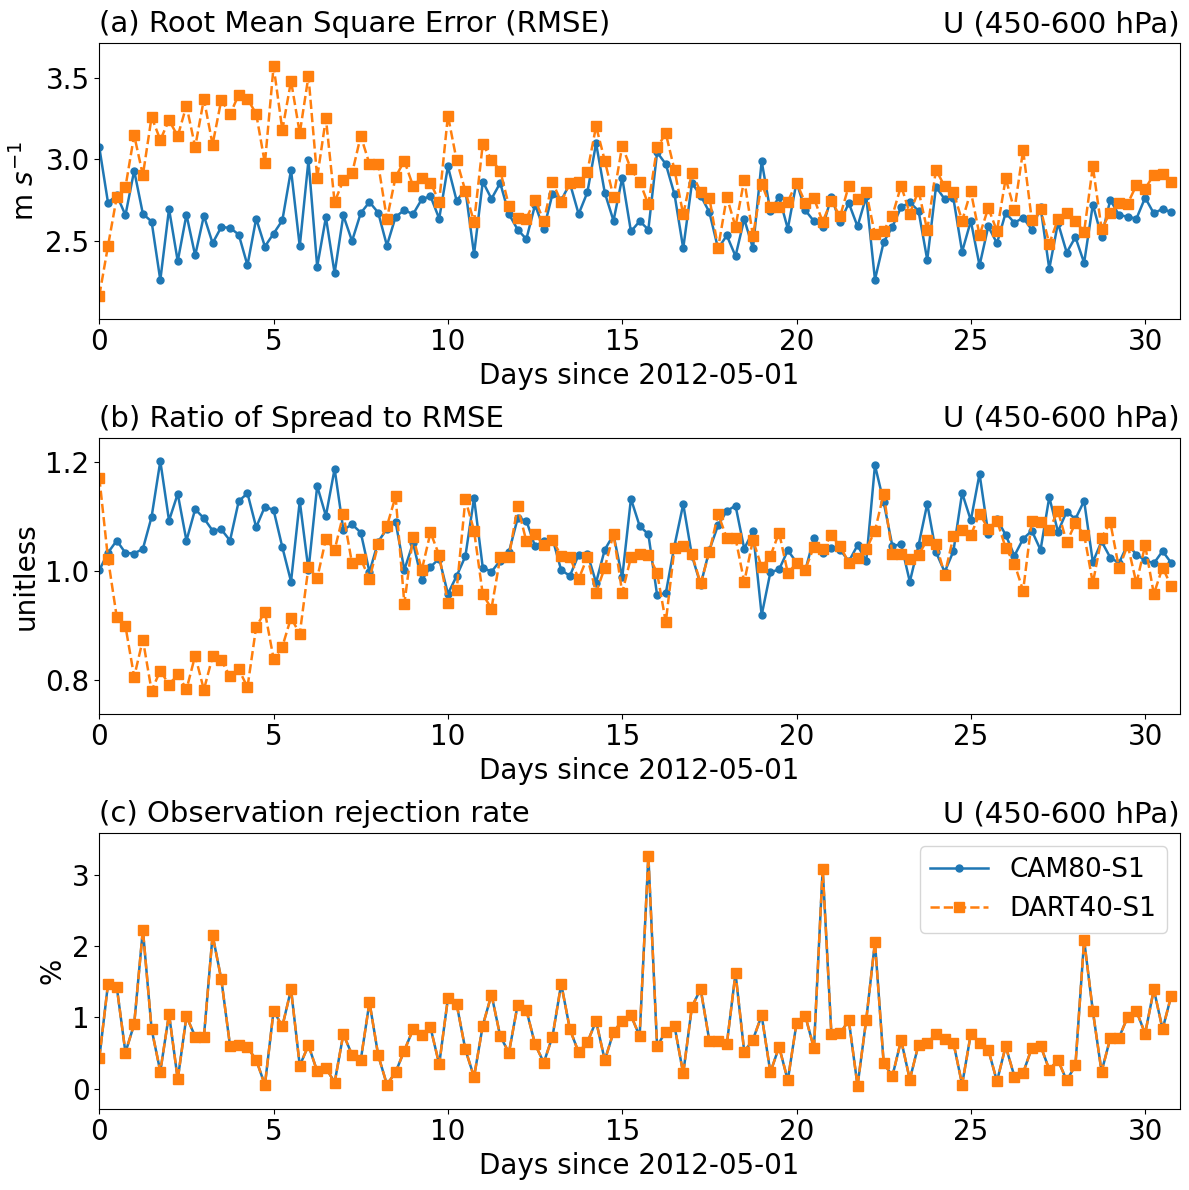

Plotting common_s1: U_WIND 225-275 hPa


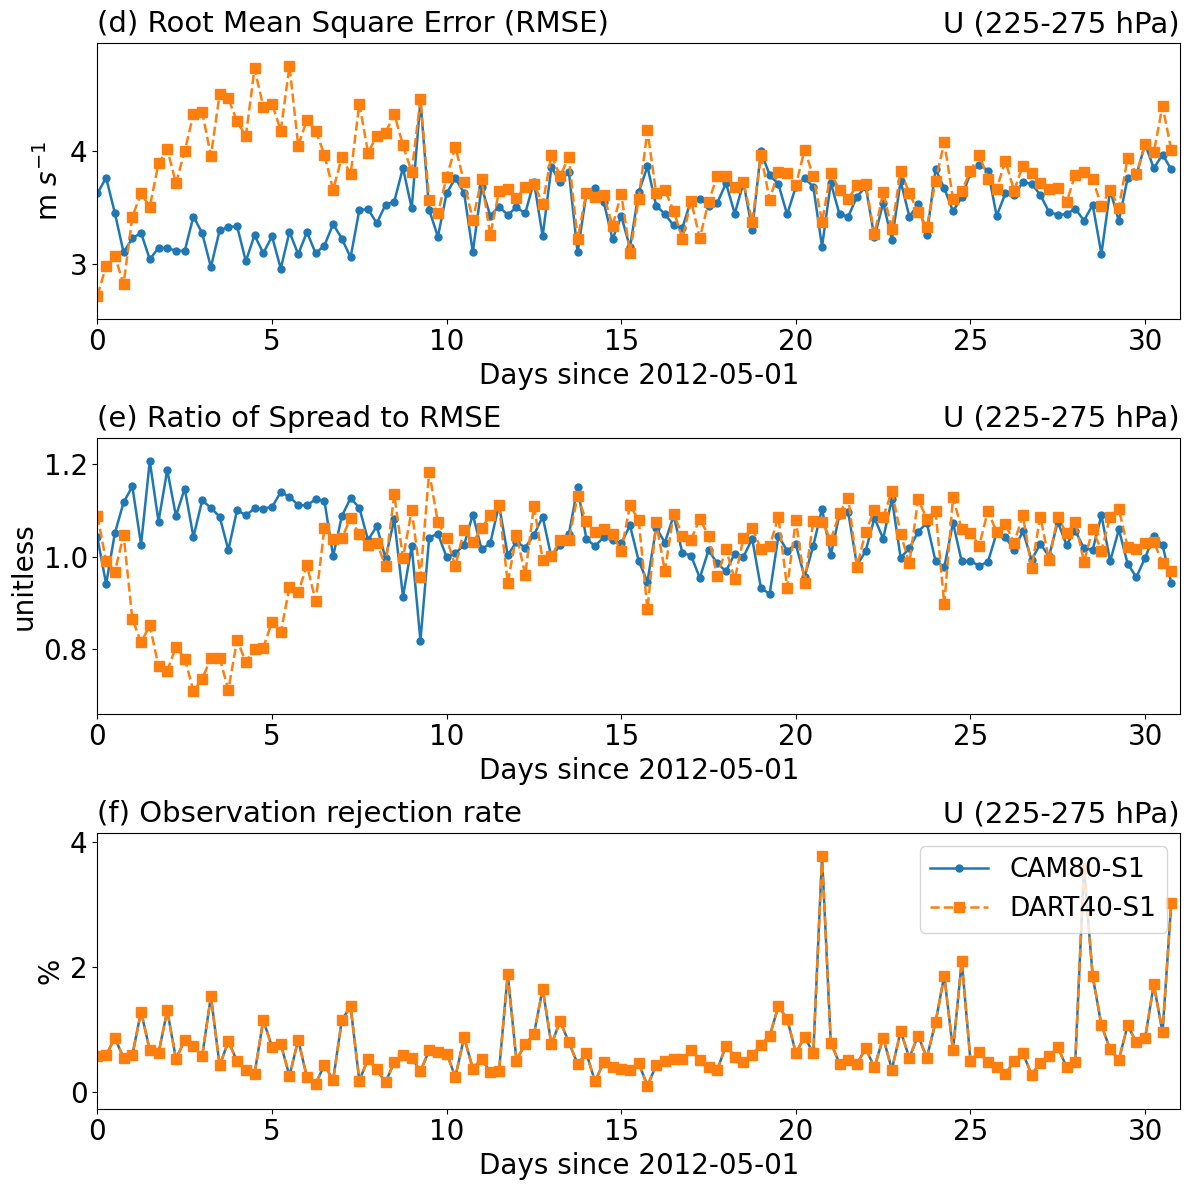

Found match for variable V_WIND in Conventional: RADIOSONDE_V_WIND_COMPONENT
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/cam6_common/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Found match for variable V_WIND in Conventional: DROPSONDE_V_WIND_COMPONENT
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnosti

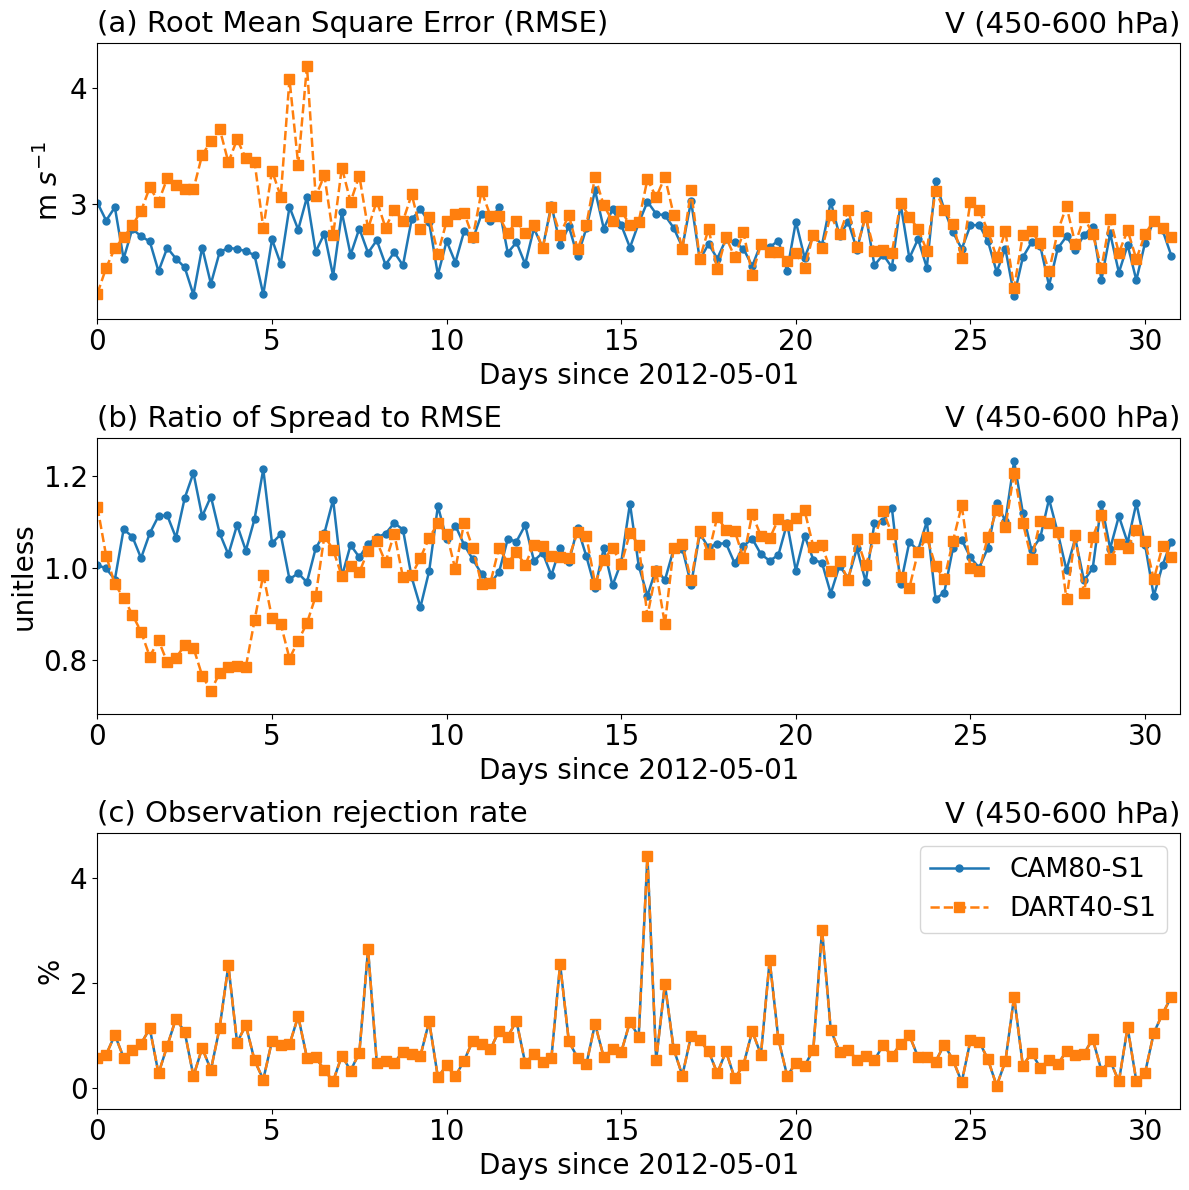

Plotting common_s1: V_WIND 225-275 hPa


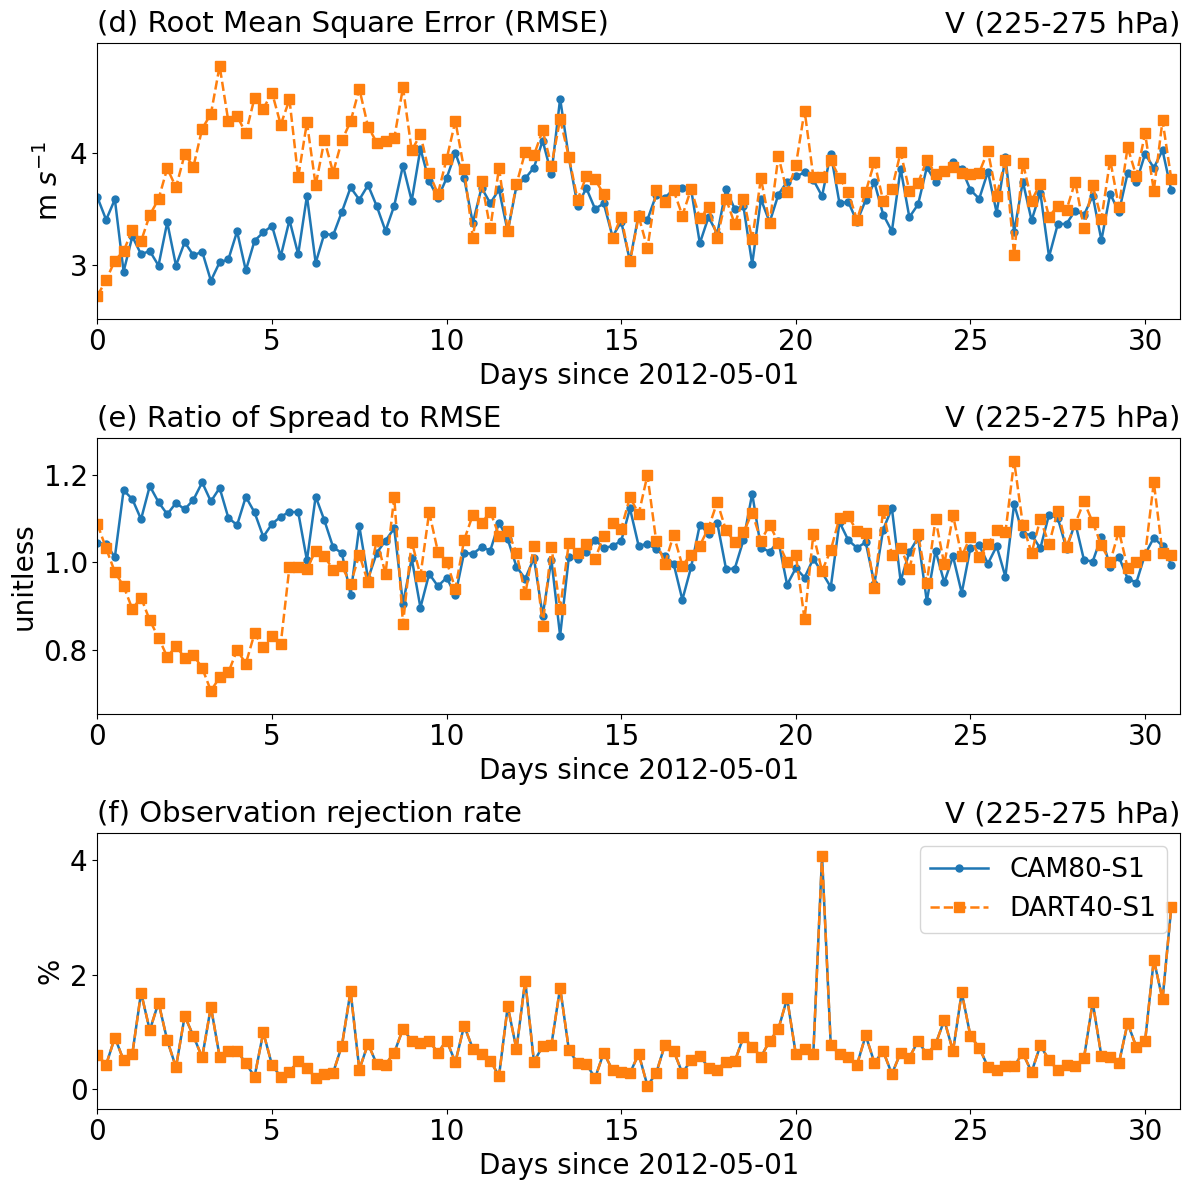

Found match for variable Temperature in Conventional: TEMPERATURE
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/cam6_common/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Found match for variable Temperature in Conventional: RADIOSONDE_TEMPERATURE
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/cam6_co

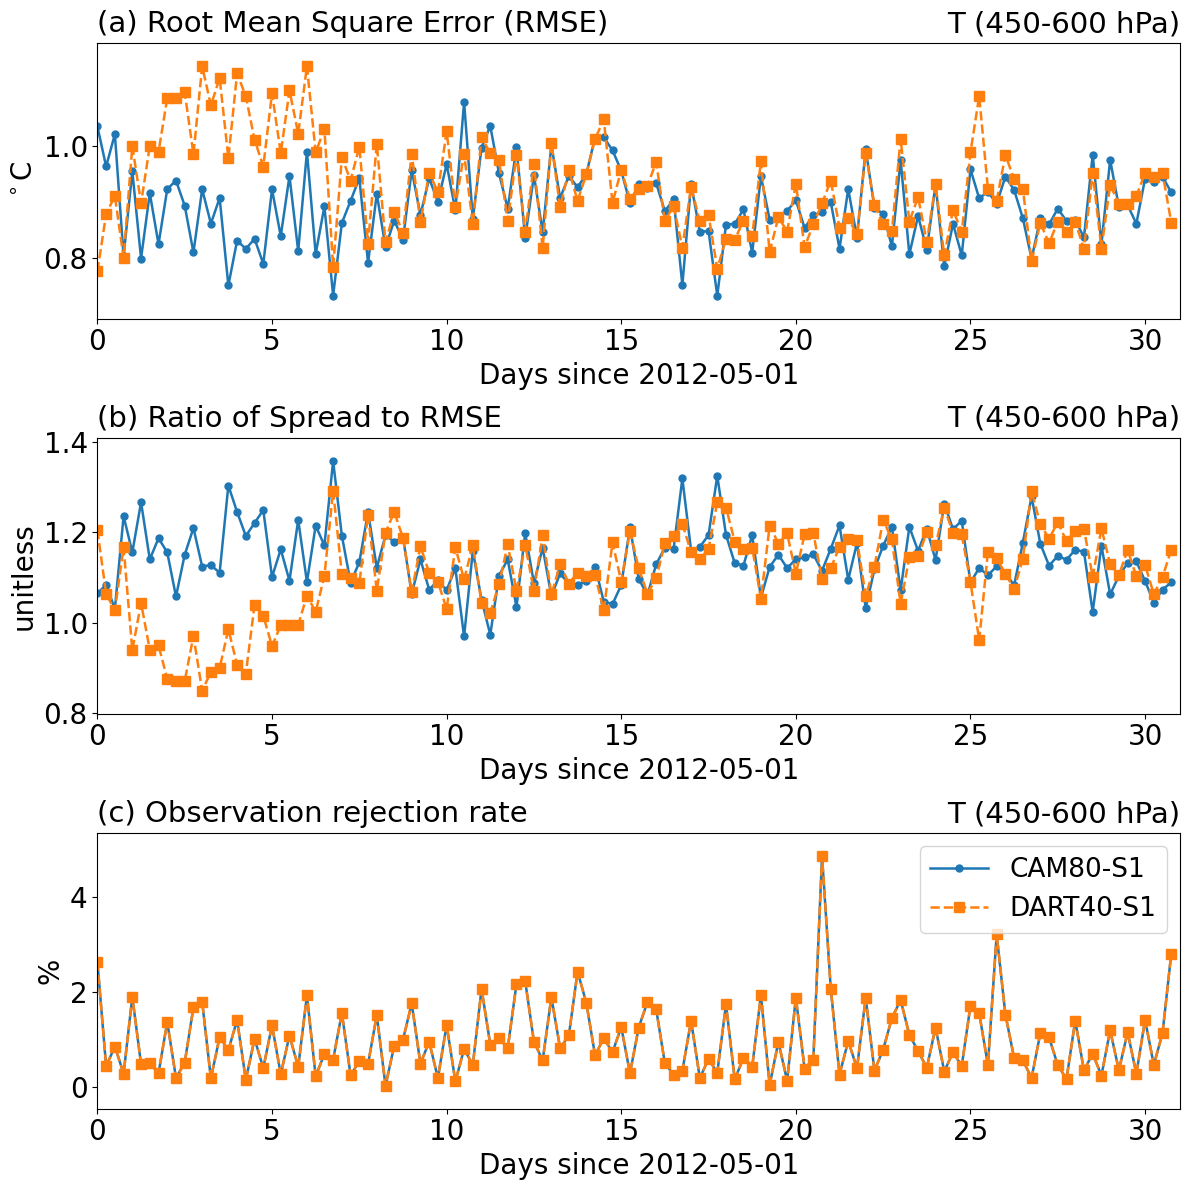

Plotting common_s1: Temperature 225-275 hPa


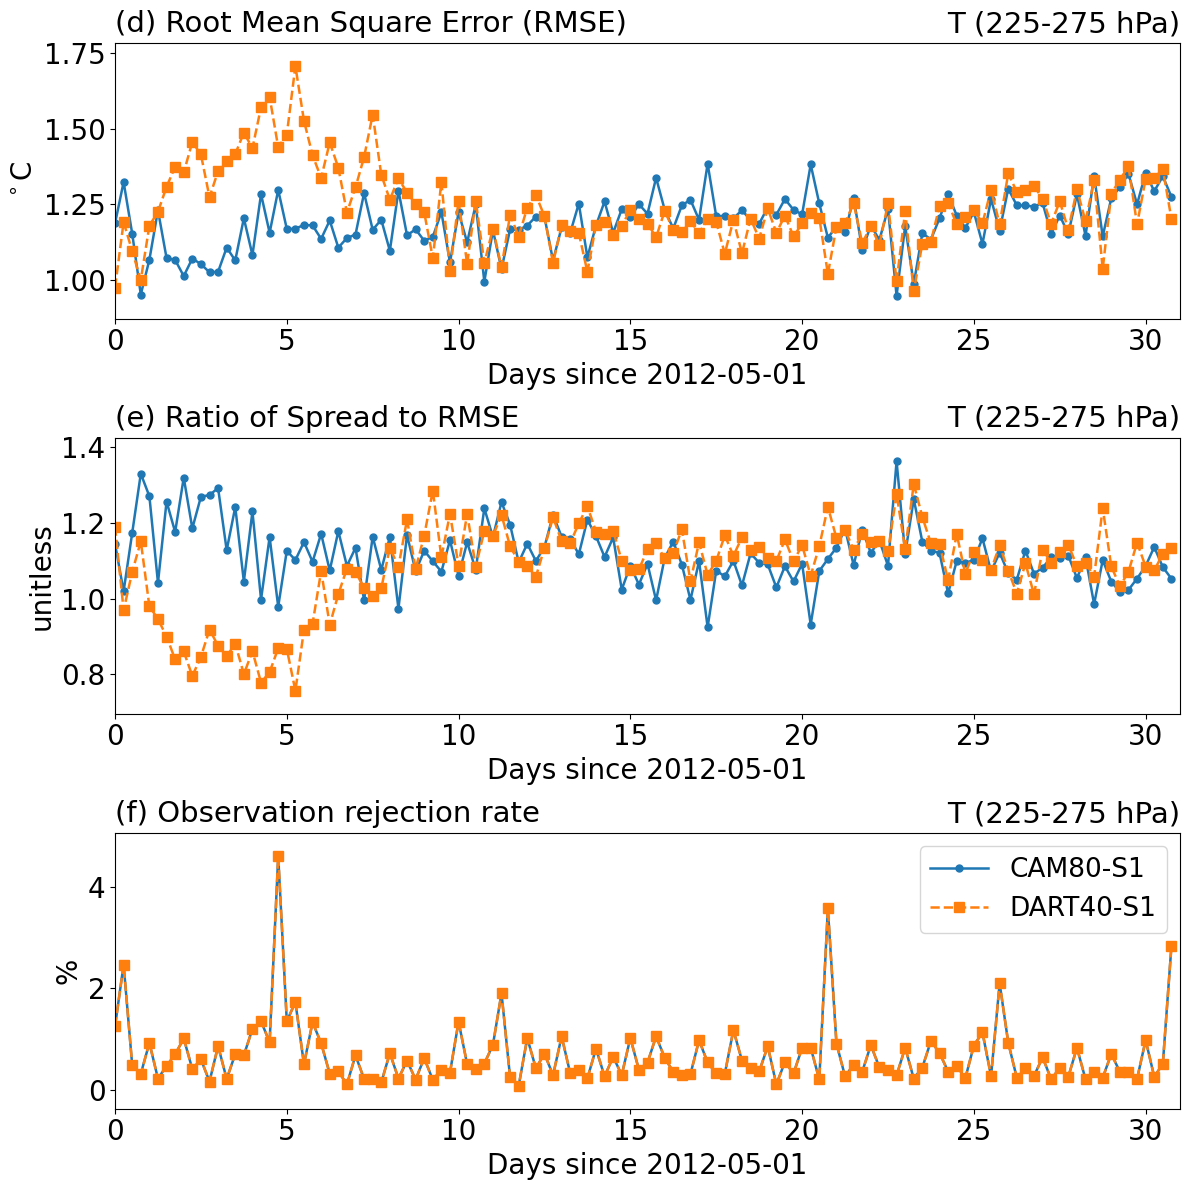

Found match for variable Humidity in Conventional: SPECIFIC_HUMIDITY
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/cam6_common/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Found match for variable Humidity in Conventional: RADIOSONDE_SPECIFIC_HUMIDITY
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/f.e22.FHIST_BGC.f09_025.CAM6assim.011/archive/dart_en80/dart_diagnostics/cam6_common/f.e22.FHIST_BGC.f09_025.CAM6assim.011.dart.e.eam_obs_diag_output.2012050100-2012060100.nc
Reading file(s): /compyfs/zhan391/v3_dart_cda_scratch/DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/dart_en40/dart_diagnostics/c

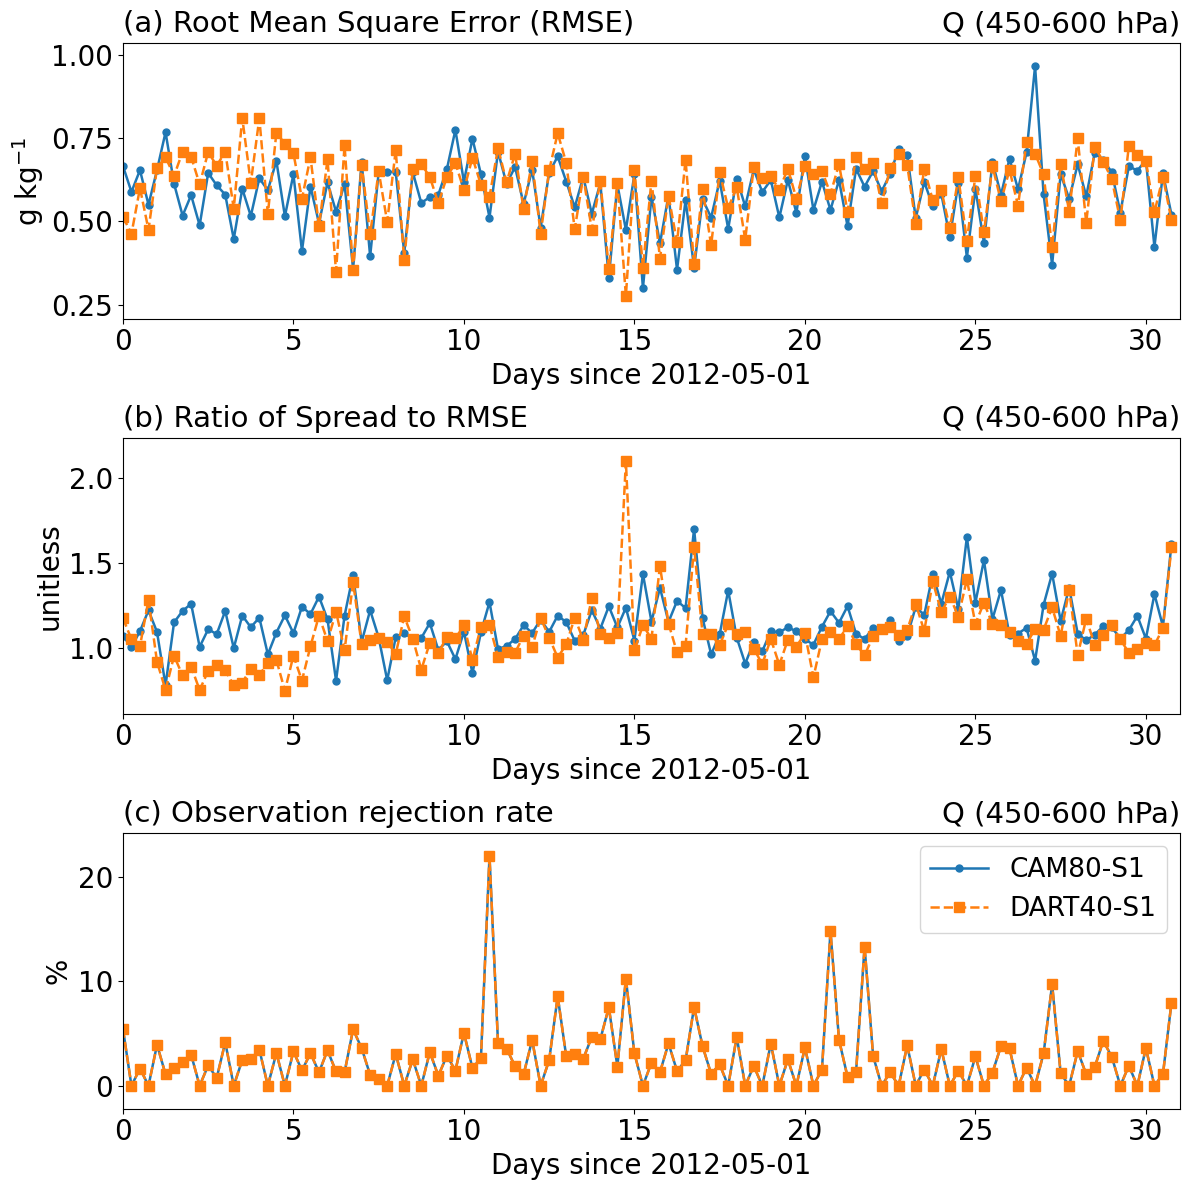

Plotting common_s1: Humidity 225-275 hPa


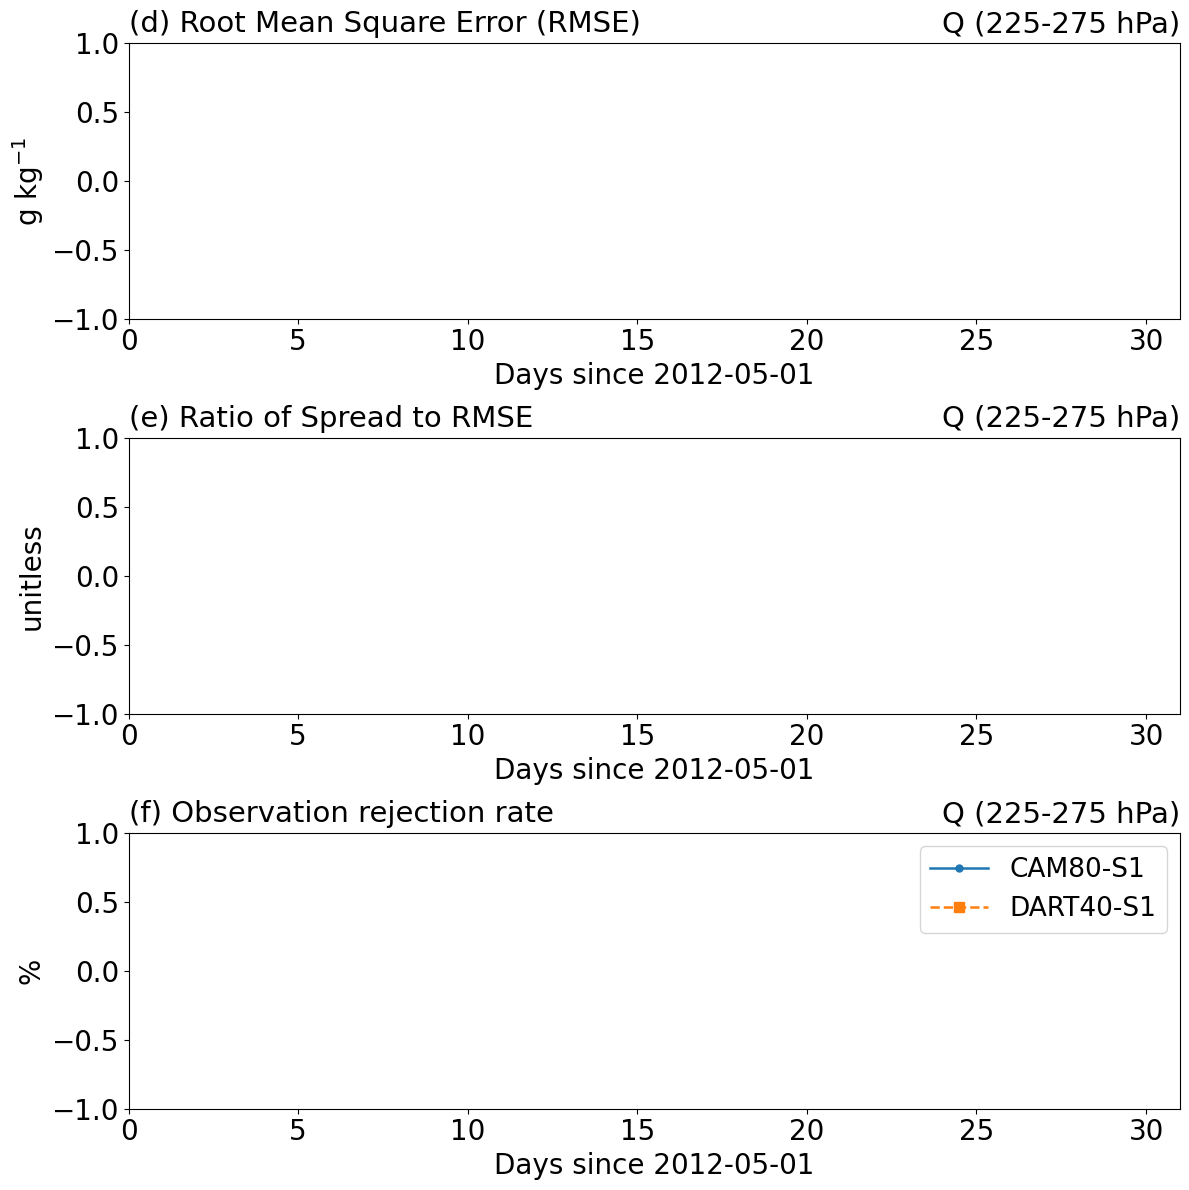

In [5]:
def _make_metric_dict(unit):
    metric_dict = {key: dict(value) for key, value in DEFAULT_METRICS.items()}
    metric_dict["rmse"]["unit"] = unit
    return metric_dict


def _find_obs_matches(reader, varstr, varlev):
    all_obs = reader.extract_obs_group()
    matches = [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]
    if not matches:
        raise RuntimeError(
            f"No matches for var='{varstr}' at level like '{varlev}' "
            "(excluding Satellite). Check your obs groups."
        )
    return matches


def run_diagnostics_compare(mode=PLOT_MODE, use_dask=True, dask_chunks=None, persist_means=False):
    if mode not in MODE_CONFIGS:
        raise ValueError(f"Unknown PLOT_MODE={mode!r}. Available: {sorted(MODE_CONFIGS)}")

    from importlib import reload
    import util.dart_obs_diag as dart_obs_diag_module

    reader_cls = reload(dart_obs_diag_module).DartObsDiagReader
    out_path = str(DIAG_DATA_DIR / "analysis_da" / "obs_diagnostics" / "time_series")
    fig_path = str(DIAG_FIGURE_DIR / "analysis_da" / "obs_diagnostics" / "time_series")

    mode_cfg = MODE_CONFIGS[mode]
    dask_client = configure_dask(use_distributed=False) if use_dask else None
    dask_chunks = dask_chunks or {"time": 31, "copy": -1, "plevel": -1, "region": 1}

    exp_info = extract_exp_info()
    exp_cfg = dict(exp_info["global"])
    if use_dask:
        exp_cfg.update({
            "dask_chunks": dask_chunks,
            "return_dask": True,
            "persist_arrays": False,
        })
    exp_dict = {
        exp_name: exp_info["experiments"][exp_name]
        for exp_name in mode_cfg["experiments"]
    }

    regnam = REGION_NAMES.get(REGION, REGION)
    reader = reader_cls(exp_cfg)

    for varstr, varcfg in mode_cfg["variables"].items():
        varlev = varcfg["lev"]
        dtype = varcfg.get("dtype", "guess")
        plot_levs = varcfg.get("plot_levs")
        metric_dict = _make_metric_dict(varcfg.get("unit"))
        diagnostic_keys = list(metric_dict.keys())

        matches = _find_obs_matches(reader, varstr, varlev)

        data_dict = {}
        lev_dict = {}
        for vgroup, vlev, vname in matches:
            print(f"Found match for variable {varstr} in {vgroup}: {vname}")
            var_dict = reader.build_ts_var_dict(
                varstr,
                name=vname,
                y1axis=varcfg.get("y1axis"),
                y2axis=varcfg.get("y2axis"),
            )
            dat, levs = reader.extract_metrics_data(
                var=varstr,
                var_dict=var_dict[varstr],
                dtype=dtype,
                regnam=regnam,
                diag_set=mode_cfg["diag_set"],
                exp_dict=exp_dict,
            )
            data_dict[vname] = dat
            lev_dict[vname] = levs

        plotter = ObsDiagPlotter(
            var=None,
            var_dict=None,
            data_dict=None,
            plevstr=None,
            regnam=regnam,
            fig_path=fig_path,
        )

        lev_str = plotter.check_flat_lev_consistency(lev_dict)
        if not lev_str:
            raise RuntimeError("Pressure levels inconsistent across variables; cannot proceed.")

        data_dict_mean = plotter.compute_experiment_means(
            data_dict,
            diagnostic_keys,
            persist=persist_means,
        )
        final_var_dict = plotter.build_ts_var_dict(
            varstr,
            name=varcfg.get("name", varstr),
            y1axis=varcfg.get("y1axis"),
            y2axis=varcfg.get("y2axis"),
        )

        plotter.var = varcfg.get("name", varstr)
        plotter.var_dict = final_var_dict
        plotter.data_dict = data_dict_mean
        plotter.plevstr = lev_str

        levels_to_plot = lev_str if plot_levs is None else plot_levs
        for i, lev in enumerate(levels_to_plot):
            if lev not in lev_str:
                print(f"[WARN] Level {lev!r} not available for {varstr}. Skipping.")
                continue
            print(f"Plotting {mode}: {varstr} {lev}")
            fig_idx = i * len(metric_dict)
            plotter.plot_timeseries(
                lev,
                xmin=XMIN,
                xmax=XMAX,
                xunit=mode_cfg["tunit"],
                fontz=FONT_SIZE,
                dpi=DPI,
                fig_idx=fig_idx,
                show=SHOW,
                save=SAVE,
                metric_dict=metric_dict,
                panel_width=PANEL_WIDTH,
                panel_height=PANEL_HEIGHT,
            )


run_diagnostics_compare(PLOT_MODE)